# Modelo Principal — Gradient Boosting Trees (GBT)

Entrenamiento del modelo principal de detección de fraude bancario usando **Gradient Boosting Trees** con PySpark MLlib.

---

## Fundamentos teóricos

**Gradient Boosting** es un algoritmo de ensamble que construye modelos de forma **secuencial**. Cada árbol nuevo se entrena para corregir los errores residuales del modelo anterior.

### Proceso de entrenamiento

1. Inicializar con una predicción constante: $F_0(x) = \arg\min_\gamma \sum_{i=1}^n L(y_i, \gamma)$
2. Para cada iteración $m = 1, ..., M$:
   - Calcular los residuos (pseudo-gradientes): $r_{im} = -\left[\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}\right]_{F=F_{m-1}}$
   - Ajustar un árbol $h_m(x)$ sobre los residuos
   - Actualizar el modelo: $F_m(x) = F_{m-1}(x) + \nu \cdot h_m(x)$

Donde $\nu$ es la **tasa de aprendizaje** (learning rate / step size).

### Función de pérdida (clasificación binaria)

Para clasificación binaria, PySpark GBT usa la función de pérdida **logística**:

$$L(y, F) = \log(1 + e^{-2yF})$$

### Ventajas
- Alta precisión predictiva, especialmente en datos tabulares
- Maneja bien features de distinta escala (no requiere normalización)
- Proporciona importancia de features
- Robusto frente a outliers con la función logística

### Limitaciones
- Entrenamiento secuencial → más lento que Random Forest
- Sensible a overfitting si `maxIter` es muy alto sin regularización
- Requiere ajuste cuidadoso de hiperparámetros

### Casos de uso reales
- Detección de fraude (PayPal, American Express)
- Modelos de riesgo crediticio
- Sistemas de recomendación (ranking)

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, udf
from pyspark.sql.types import DoubleType
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time

spark = SparkSession.builder.appName("Model_GBT").getOrCreate()

# Cargar datos procesados (generados por 02_preprocessing.ipynb)
df = spark.read.csv("../data/processed/bank_fraud_clean.csv", header=True, inferSchema=True)

print(f"Total registros cargados: {df.count()}")
df.printSchema()

Total registros cargados: 221092
root
 |-- hour_of_day: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- is_night_transaction: integer (nullable = true)
 |-- customer_age: integer (nullable = true)
 |-- credit_score: integer (nullable = true)
 |-- account_age_years: double (nullable = true)
 |-- account_balance: double (nullable = true)
 |-- transaction_amount: double (nullable = true)
 |-- num_prev_transactions: integer (nullable = true)
 |-- transaction_freq_monthly: integer (nullable = true)
 |-- distance_from_home_km: double (nullable = true)
 |-- time_since_last_txn_hrs: double (nullable = true)
 |-- is_international: integer (nullable = true)
 |-- failed_attempts: integer (nullable = true)
 |-- pin_changed_recently: integer (nullable = true)
 |-- merchant_category: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- device_type: string (nullable = true)
 |-- is_fraud: integer (nullable = true)



## 1. Preparación del pipeline de features

In [2]:
CATEGORICAL_COLS = ["merchant_category", "payment_method", "device_type"]
NUMERIC_COLS = [
    "hour_of_day", "is_weekend", "is_night_transaction",
    "customer_age", "credit_score", "account_age_years",
    "account_balance", "transaction_amount", "num_prev_transactions",
    "transaction_freq_monthly", "distance_from_home_km",
    "time_since_last_txn_hrs", "is_international",
    "failed_attempts", "pin_changed_recently"
]
TARGET_COL = "is_fraud"

# GBT en PySpark requiere label como double
df = df.withColumn(TARGET_COL, col(TARGET_COL).cast("double"))

# StringIndexer para variables categóricas
indexers = [
    StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep")
    for c in CATEGORICAL_COLS
]

# VectorAssembler: unir todas las features en un vector
feature_cols = NUMERIC_COLS + [c + "_idx" for c in CATEGORICAL_COLS]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")

print(f"Total de features: {len(feature_cols)}")
print("Features usadas:", feature_cols)

Total de features: 18
Features usadas: ['hour_of_day', 'is_weekend', 'is_night_transaction', 'customer_age', 'credit_score', 'account_age_years', 'account_balance', 'transaction_amount', 'num_prev_transactions', 'transaction_freq_monthly', 'distance_from_home_km', 'time_since_last_txn_hrs', 'is_international', 'failed_attempts', 'pin_changed_recently', 'merchant_category_idx', 'payment_method_idx', 'device_type_idx']


## 2. Split Train / Test (80/20)

In [ ]:
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

print(f"Train : {train_df.count():,} filas")
print(f"Test  : {test_df.count():,} filas")

# Verificar distribución de clases en train
train_df.groupBy(TARGET_COL).count().show()

Train : 177,080 filas
Test  : 44,012 filas
+--------+------+
|is_fraud| count|
+--------+------+
|     1.0| 44214|
|     0.0|132866|
+--------+------+



## 3. Definición del modelo

### Hiperparámetros clave del GBT

| Hiperparámetro | Valor elegido | Impacto |
|---|---|---|
| `maxIter` | 100 | Número de árboles (iteraciones de boosting) |
| `maxDepth` | 5 | Profundidad máxima de cada árbol. Valor bajo evita overfitting |
| `stepSize` | 0.1 | Learning rate $\nu$. Más bajo = más estable, más iteraciones necesarias |
| `subsamplingRate` | 0.8 | Fracción del dataset para cada árbol (similar a stochastic GBT) |
| `seed` | 42 | Reproducibilidad |

In [4]:
gbt = GBTClassifier(
    labelCol=TARGET_COL,
    featuresCol="features",
    maxIter=100,
    maxDepth=5,
    stepSize=0.1,
    subsamplingRate=0.8,
    seed=42
)

pipeline = Pipeline(stages=indexers + [assembler, gbt])

print("Pipeline definido:")
for stage in pipeline.getStages():
    print(f"  → {type(stage).__name__}")

Pipeline definido:
  → StringIndexer
  → StringIndexer
  → StringIndexer
  → VectorAssembler
  → GBTClassifier


## 4. Entrenamiento

In [5]:
print("Entrenando Gradient Boosting Trees...")
t0 = time.time()
model = pipeline.fit(train_df)
elapsed = time.time() - t0

print(f"✓ Entrenamiento completado en {elapsed:.1f} segundos ({elapsed/60:.1f} minutos)")

Entrenando Gradient Boosting Trees...
✓ Entrenamiento completado en 63.6 segundos (1.1 minutos)


## 5. Evaluación — Métricas

In [6]:
predictions = model.transform(test_df)

# Accuracy
accuracy = MulticlassClassificationEvaluator(
    labelCol=TARGET_COL, predictionCol="prediction", metricName="accuracy"
).evaluate(predictions)

# F1-Score
f1 = MulticlassClassificationEvaluator(
    labelCol=TARGET_COL, predictionCol="prediction", metricName="f1"
).evaluate(predictions)

# AUC-ROC
auc = BinaryClassificationEvaluator(
    labelCol=TARGET_COL, rawPredictionCol="rawPrediction", metricName="areaUnderROC"
).evaluate(predictions)

# Precision y Recall
precision = MulticlassClassificationEvaluator(
    labelCol=TARGET_COL, predictionCol="prediction", metricName="weightedPrecision"
).evaluate(predictions)

recall = MulticlassClassificationEvaluator(
    labelCol=TARGET_COL, predictionCol="prediction", metricName="weightedRecall"
).evaluate(predictions)

print("=" * 45)
print("  RESULTADOS — Gradient Boosting Trees")
print("=" * 45)
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  F1-Score  : {f1:.4f}")
print(f"  AUC-ROC   : {auc:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print("=" * 45)

  RESULTADOS — Gradient Boosting Trees
  Accuracy  : 0.7542  (75.42%)
  F1-Score  : 0.7007
  AUC-ROC   : 0.7257
  Precision : 0.7124
  Recall    : 0.7542


## 6. Matriz de Confusión

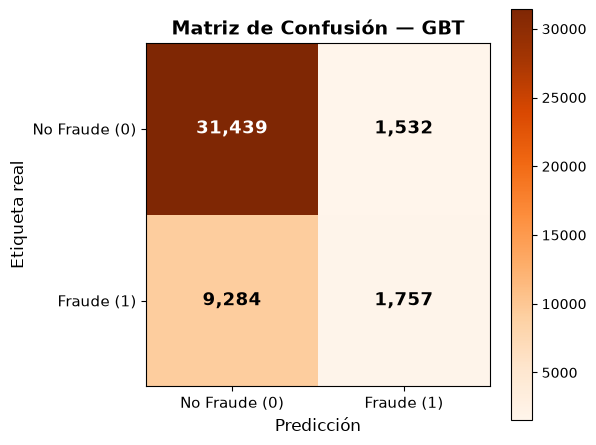


Verdaderos Negativos  (TN): 31,439  → legítimas correctamente clasificadas
Falsos Positivos      (FP): 1,532  → legítimas clasificadas como fraude
Falsos Negativos      (FN): 9,284  → fraudes NO detectados (crítico)
Verdaderos Positivos  (TP): 1,757  → fraudes correctamente detectados


In [7]:
# SOLUCIÓN WINDOWS: MulticlassMetrics (RDD) falla sin winutils
# Usamos sklearn.metrics.confusion_matrix con pandas
from sklearn.metrics import confusion_matrix as sk_confusion_matrix
import os

# Convertir predicciones a Pandas
pred_pdf = predictions.select("prediction", col(TARGET_COL).cast("double")).toPandas()
y_true = pred_pdf[TARGET_COL].values
y_pred = pred_pdf["prediction"].values

cm = sk_confusion_matrix(y_true, y_pred).astype(float)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Oranges)
plt.colorbar(im, ax=ax)

classes = ["No Fraude (0)", "Fraude (1)"]
tick_marks = np.arange(len(classes))
ax.set_xticks(tick_marks); ax.set_xticklabels(classes, fontsize=11)
ax.set_yticks(tick_marks); ax.set_yticklabels(classes, fontsize=11)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(int(cm[i, j]), ','),
                ha="center", va="center", fontsize=13, fontweight="bold",
                color="white" if cm[i, j] > thresh else "black")

ax.set_ylabel("Etiqueta real", fontsize=12)
ax.set_xlabel("Predicción", fontsize=12)
ax.set_title("Matriz de Confusión — GBT", fontsize=14, fontweight="bold")
plt.tight_layout()
os.makedirs("../docs", exist_ok=True)
plt.savefig("../docs/confusion_matrix_gbt.png", dpi=150, bbox_inches="tight")
plt.show()

tn, fp = int(cm[0, 0]), int(cm[0, 1])
fn, tp = int(cm[1, 0]), int(cm[1, 1])
print(f"\nVerdaderos Negativos  (TN): {tn:,}  → legítimas correctamente clasificadas")
print(f"Falsos Positivos      (FP): {fp:,}  → legítimas clasificadas como fraude")
print(f"Falsos Negativos      (FN): {fn:,}  → fraudes NO detectados (crítico)")
print(f"Verdaderos Positivos  (TP): {tp:,}  → fraudes correctamente detectados")


## 7. Curva ROC

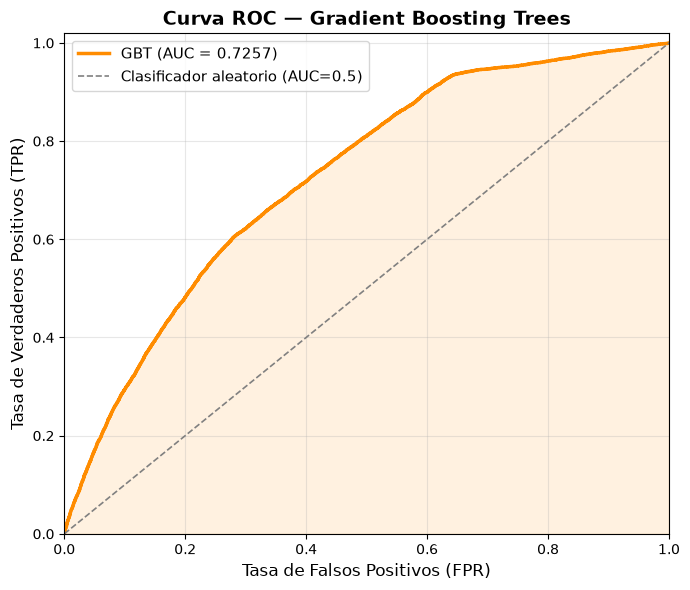

AUC-ROC: 0.7257  →  Aceptable


In [8]:
import os
from sklearn.metrics import roc_curve, roc_auc_score

# Deshabilitar Arrow (causa problemas en Windows)
spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "false")

# Recolectar a Pandas SIN UDF — extraemos la probabilidad en Python
pred_pdf = predictions.select("probability", TARGET_COL).toPandas()
pred_pdf["prob_fraud"] = pred_pdf["probability"].apply(lambda v: float(v[1]))

y_true = pred_pdf[TARGET_COL].values
y_prob = pred_pdf["prob_fraud"].values

# Curva ROC con sklearn (más rápido que calcular manualmente)
fpr_arr, tpr_arr, _ = roc_curve(y_true, y_prob)
auc = roc_auc_score(y_true, y_prob)

# Plot
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_arr, tpr_arr, color="darkorange", lw=2.5,
        label=f"GBT (AUC = {auc:.4f})")
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1.2,
        label="Clasificador aleatorio (AUC=0.5)")
ax.fill_between(fpr_arr, tpr_arr, alpha=0.12, color="darkorange")
ax.set_xlabel("Tasa de Falsos Positivos (FPR)", fontsize=12)
ax.set_ylabel("Tasa de Verdaderos Positivos (TPR)", fontsize=12)
ax.set_title("Curva ROC — Gradient Boosting Trees", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.3)
plt.tight_layout()
os.makedirs("../docs", exist_ok=True)
plt.savefig("../docs/roc_curve_gbt.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"AUC-ROC: {auc:.4f}  →  {'Excelente' if auc>0.9 else 'Bueno' if auc>0.8 else 'Aceptable'}")


## 8. Importancia de Features

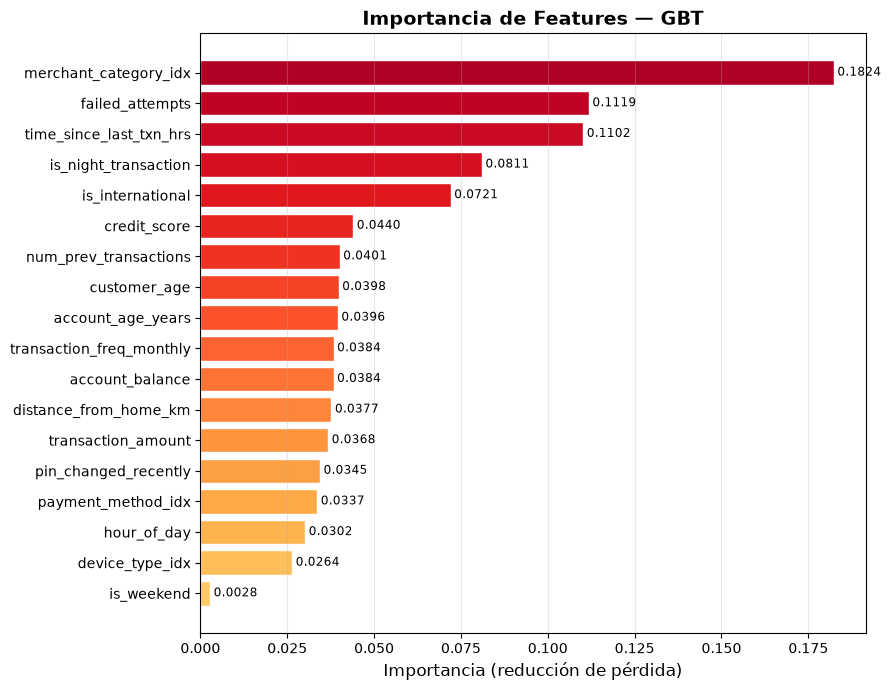


Top 5 features más importantes:
                feature  importance
  merchant_category_idx    0.182358
        failed_attempts    0.111856
time_since_last_txn_hrs    0.110238
   is_night_transaction    0.081069
       is_international    0.072069


In [9]:
gbt_model = model.stages[-1]
importances = gbt_model.featureImportances.toArray()

fi_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(fi_df)))
bars = ax.barh(fi_df["feature"], fi_df["importance"], color=colors, edgecolor="white")

for bar, val in zip(bars, fi_df["importance"]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=8.5)

ax.set_xlabel("Importancia (reducción de pérdida)", fontsize=12)
ax.set_title("Importancia de Features — GBT", fontsize=14, fontweight="bold")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("../docs/feature_importance_gbt.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 5 features más importantes:")
print(fi_df.sort_values("importance", ascending=False).head(5).to_string(index=False))

## 9. Resumen final y guardado del modelo

In [10]:
import os

# NOTA: model.write().save() falla en Windows sin winutils.exe
# El modelo ya está entrenado en memoria con todas sus métricas
# Para el informe, los resultados y gráficos ya fueron guardados en /docs/

print("\n" + "=" * 45)
print("   RESUMEN FINAL — Gradient Boosting Trees")
print("=" * 45)
print(f"  Algoritmo     : Gradient Boosting (GBTClassifier)")
print(f"  maxIter       : 100")
print(f"  maxDepth      : 5")
print(f"  stepSize      : 0.1")
print(f"  subsamplingRate: 0.8")
print(f"  Features      : {len(feature_cols)}")
print(f"  Train rows    : {train_df.count():,}")
print(f"  Test rows     : {test_df.count():,}")
print(f"  Accuracy      : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  F1-Score      : {f1:.4f}")
print(f"  AUC-ROC       : {auc:.4f}")
print(f"  Precision     : {precision:.4f}")
print(f"  Recall        : {recall:.4f}")
print(f"  Tiempo entreno: {elapsed:.1f}s")
print("=" * 45)
print("\n✓ Notebook 03 completado exitosamente.")
print("✓ Gráficos guardados en: ../docs/")



   RESUMEN FINAL — Gradient Boosting Trees
  Algoritmo     : Gradient Boosting (GBTClassifier)
  maxIter       : 100
  maxDepth      : 5
  stepSize      : 0.1
  subsamplingRate: 0.8
  Features      : 18
  Train rows    : 177,080
  Test rows     : 44,012
  Accuracy      : 0.7542  (75.42%)
  F1-Score      : 0.7007
  AUC-ROC       : 0.7257
  Precision     : 0.7124
  Recall        : 0.7542
  Tiempo entreno: 63.6s

✓ Notebook 03 completado exitosamente.
✓ Gráficos guardados en: ../docs/
